# Imports

In [61]:
import Neural_Network_module
import pandas as pd
import pennylane as qml
import torch
import torch.nn as nn
import numpy as np
from tqdm import tqdm
from sklearn.metrics import mean_squared_error
import matplotlib.pyplot as plt
import seaborn as sns
from torchviz import make_dot
import numpy as np

# Read DF

In [62]:
selected_features = ['Operational setting 1', 'Ps30', 'phi', 'Nc', 'T30', 'W31']

filepath = r'C:\Users\mathi\OneDrive\Documents\Studia\SGH\Semestr 4\Praca dyplomowa'
df = pd.read_excel(f'{filepath}/Output/Preprocessed.xlsx',sheet_name='Scaled DF',usecols=selected_features)
X = torch.tensor(df.values, dtype=torch.float32)

df_original = pd.read_excel(f'{filepath}/Output/Preprocessed.xlsx',sheet_name='Scaled DF')
df_original['Data']='Original'

df.head()

,Operational setting 1,T30,Nc,Ps30,phi,W31
0,-0.080460,-0.186396,-0.780490,-0.261905,0.266525,0.426357
1,0.218391,-0.093961,-0.799515,-0.238095,0.530917,0.333333
2,-0.494253,-0.260955,-0.719914,-0.500000,0.590618,0.255814
3,0.080460,-0.487683,-0.750965,-0.666667,0.778252,0.147287
4,-0.218391,-0.485066,-0.700081,-0.488095,0.492537,0.178295


# Quantum Model

In [63]:
n_qubits  = len(df.iloc[0,:]) # Number of features
n_latent  = 2 # Number of latent qubits i.e. comression to 2 qubits
n_trash   = n_qubits - n_latent
n_layers  = 2          # głębokość ansatzu (warstw entanglingowych)

latent_wires = list(range(n_latent))                  # np. [0,1]
trash_wires  = list(range(n_latent, n_qubits))        # np. [2,3,4,5]
BATCH_SIZE = 870


dev = qml.device("default.qubit", wires=n_qubits, shots=None)


# Przydatne: kształt wag StronglyEntanglingLayers
weight_shape = (n_layers, n_qubits)

### Encoder

In [64]:
def encoder(weights):
    """Encoder function.
    Entangles qubits and sets their Y rotation

    Args:
        weights (_type_): _description_
    """
    # iterate over layers
    for layer in range(n_layers):
        #qml.BasicEntanglerLayers(weights=weights, wires=range(n_qubits))
        # Encode rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)

        # Entangling CNOTs in a chain
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

### Decoder

In [65]:
def decoder(weights):
    """Decoder Function
    Entangles qubits and sets their Y rotation

    Args:
        weights (_type_): _description_
    """
   # iterate over layers
    for layer in range(n_layers):
        # Encode rotations
        for i in range(n_qubits):
            qml.RY(weights[layer, i], wires=i)

        # Entangling CNOTs in a chain
        for i in range(n_qubits - 1):
            qml.CNOT(wires=[i, i + 1])

### Qnode Full Autoencoder

In [66]:
# Batched version of decode_qnode
@qml.qnode(dev, interface="torch", diff_method="best")  # adjoint zwykle przyspiesza
def decode_qnode_batch(X_batch, encoder_weight, decoder_weight):
    qml.AngleEmbedding(
        X_batch, wires=range(n_qubits), rotation="Y")
    encoder(encoder_weight)
    decoder(decoder_weight)
    # broadcast: dostaniesz tensory o kształcie (B, n_qubits)
    return [qml.expval(qml.PauliZ(i)) for i in range(n_qubits)]

### Qnode for trash wires probabilty measurement




In [67]:
@qml.qnode(dev, interface="torch", diff_method="best")
def trash_zero_qnode_batch(X_batch, encoder_weight):
    qml.AngleEmbedding(
        X_batch, wires=range(n_qubits), rotation="Y")
   
    encoder(encoder_weight)
    # broadcast: kształt (B, 2**n_trash)
    probs = qml.probs(wires=trash_wires)
    return probs

### Qnode for latent state measurement




In [68]:
@qml.qnode(dev, interface="torch", diff_method="best")
def latent_state_values(x, encoder_weights):
    """Qnode used to measure the latent (nottleneck) layer

    Args:
        x (list): list of values used as entry
        encoder_weights (torch.tensor): list of weights for the encoder

    Returns:
        torch.tensor: list of expected values of Pauli Z measurements of each latent cubits. Values [-1,1]
    """
    # Load data into quantum state
    qml.AngleEmbedding(x, wires=range(n_qubits), rotation='Y')

    # Encode data: entangler and rotations
    encoder(encoder_weights)

    # Perform PauliZ measurment and get expected values for tyhose measurments
    pauli_z_exp = [qml.expval(qml.PauliZ(w)) for w in latent_wires]

    return pauli_z_exp

### Pytorch Model

In [69]:
class QuantumAutoencoder(nn.Module):
    def __init__(self):
        """initialize en/decoder weights
        """
        super().__init__()
        # Parametry enkodera i dekodera (trainable)
        self.encoder_weight = nn.Parameter(
            torch.rand(size=weight_shape)*0.2-0.1)

        self.decoder_weight = nn.Parameter(
            torch.rand(size=weight_shape)*0.2-0.1)

    @staticmethod
    def _scale_input(x):
        """Scaling function left for legacy purposes. Returns unaltered value. Earlier it clamped on [-pi,pi]

        Args:
            x (_type_): _description_

        Returns:
            _type_: _description_
        """
        scaled = torch.clamp(x, -3.14159, 3.14159)  # legacy
        return x

    def forward(self, x):
        """Forward pass of class

        Args:
            x (torch.tensor): single row of torch tensor containing data

        Returns:
            torch.tensor, torch.tensor: list of reconstructed data, probability of trash wires being in |0...0>
        """
        single_input_flag = False
        if x.dim() == 1:
            x = x.unsqueeze(0)  # add batch dimension if missing
            single_input_flag = True

        # x_prim = decode_qnode(x, self.encoder_weight, self.decoder_weight)
        x_prim = decode_qnode_batch(x, self.encoder_weight, self.decoder_weight)

        if isinstance(x_prim, (list, tuple)):
            x_prim = torch.stack(x_prim, dim=1)

        # Measure probabilities of trash wires being in |0...0>
        probs_trash = trash_zero_qnode_batch(x, self.encoder_weight)
        # index 0 corresponds to |0...0>
        p_zero_trash = probs_trash[:, 0]

        if single_input_flag:
            x_prim = x_prim.squeeze(0)
            p_zero_trash = p_zero_trash.squeeze(0)

        return x_prim, p_zero_trash

    @staticmethod
    def loss_fn(batch, x_prim, p_zero_trash, alpha=1.0, beta=1):
        """Loss function

        Args:
            batch (torch.tensor): tensor shape [B, n_qubits]
            x_prim (torch.tensor): reconstructed tensor [B, n_qubits]
            p_zero (torch.tensor): tensor [B] of probability of trash wires being in |0...0>
            alpha (float, optional): reconstruction loss factor. Defaults to 1.0.
            beta (float, optional): compression loss factor. Defaults to 0.5.

        Returns:
            torch.tensor : 
            total loss, 
        """       
        recon_loss = torch.mean((x_prim - batch)**2)
        compression_loss = 1.0 - torch.mean(p_zero_trash)
        total_loss = alpha*recon_loss + beta*compression_loss
        return total_loss, recon_loss.item(), compression_loss.item()

        

# Read weights from file reconstruct and calculate metrics

In [70]:
model1 = Neural_Network_module.Autoencoder_Linear1()
model2 = Neural_Network_module.Autoencoder_Linear2()
model3 = Neural_Network_module.Autoencoder_Linear3()
model4 = QuantumAutoencoder()

In [71]:
models_dict = {
    'Autoencoder 1':
               {'Model': model1,
                'Losses':[],
                'Training time':'',
                'Epochs':''},
    'Autoencoder 2':
               {'Model': model2,
                'Losses':[],
                'Training time':'',
                'Epochs':''},
    'Autoencoder 3':
               {'Model': model3,
                'Losses':[],
                'Training time':'',
                'Epochs':''},
               }

for name in models_dict.keys():
    model = models_dict[name]['Model']
    path =filepath +f'\\Code\\Models\\{name}.pth'
    checkpoint = torch.load(path)

    model.load_state_dict(checkpoint["model_state_dict"])
    model.eval()
    
    with torch.no_grad():
        x_recon = model(X)
    df_recon = pd.DataFrame(x_recon.numpy(), columns=df.columns)

    models_dict[name]['Losses'] = checkpoint["loss"]
    models_dict[name]['Training time'] = checkpoint["training_time"]
    models_dict[name]['Epochs'] = len(checkpoint["loss"])
    models_dict[name]['Reconstructed DF'] = df_recon
    models_dict[name]['Delta DF'] = df - df_recon
    models_dict[name]['MSE'] = mean_squared_error(df.values, df_recon.values)

RECON_BATCH_SIZE = 100
reconstructions = []
model4.eval()
path =filepath +f'\\Code\\Models\\quantum_autoencoder_weights.pth'
checkpoint = torch.load(path)
model4.load_state_dict(checkpoint["model_state_dict"])

with torch.no_grad():
    for batch_start in tqdm(range(0, X.shape[0], RECON_BATCH_SIZE)):
        batch_end = min(batch_start + RECON_BATCH_SIZE, X.shape[0])
        x_batch = X[batch_start:batch_end]
        x_prim, _ = model4(x_batch)
        x_numpy = x_prim.detach().cpu().numpy()
        reconstructions.append(x_numpy)
reconstructions = np.vstack(reconstructions)
df_recon_q = pd.DataFrame(reconstructions, columns=df.columns)

# Add quantum model to dictionary
models_dict['Quantum'] = {
    'Model': model4,
    'Losses': checkpoint["loss"],
    'Training time': checkpoint["training_time"],
    'Epochs': len(checkpoint["loss"]['Epoch']),
    'Reconstructed DF': df_recon_q,
    'Delta DF': df - df_recon_q,
    'MSE': mean_squared_error(df.values, df_recon_q.values)
}

100%|██████████| 207/207 [00:10<00:00, 19.46it/s]


# Detailed Summary comparison

## DF

In [72]:
def calculate_metrics(df_feature, df_recon_feature, delta_feature):
    median = delta_feature.median()
    max_delta = delta_feature.max()
    min_delta = delta_feature.min()
    q3, q1 = np.percentile(delta_feature, [75, 25])
    iqr = q3 - q1
    n_outliers = ((delta_feature < (q1 - 1.5 * iqr)) |
                  (delta_feature > (q3 + 1.5 * iqr))).sum()
    outlier_pct = n_outliers / len(delta_feature) * 100
    rmse = np.sqrt(mean_squared_error(df_feature, df_recon_feature))

    return {
        'RMSE': rmse,
        "Median": median,
        "Q1": q1,
        "Q3": q3,
        "IQR": iqr,
        "Delta min": min_delta,
        "Delta max": max_delta,
        "Outlier \%": outlier_pct
    }

In [73]:
metrics = ["RMSE", "Median", "Q1", "Q3", "IQR", "Delta min", "Delta max", "Outlier \%"]

index = pd.MultiIndex.from_product(
    [models_dict.keys(), metrics],
    names=["Model", "Metric"]
)

result_df = pd.DataFrame(
    index=index,
    columns=df.columns,
    dtype=float
)

for model_name in models_dict.keys():
    df_recon_ = models_dict[model_name]['Reconstructed DF']
    delta_df = models_dict[model_name]['Delta DF']
    for feature in delta_df.columns:
        metrics_dict = calculate_metrics(df[feature],df_recon_[feature],delta_df[feature])

        for metric, value in metrics_dict.items():
            result_df.loc[(model_name, metric), feature] = value


result_df= result_df.round(4).astype(float) 

result_df

Operational setting 1     T30      Nc    Ps30  \
Model         Metric                                                      
Autoencoder 1 RMSE                       0.2514  0.2674  0.1982  0.3180   
              Median                     0.0010 -0.0130 -0.0410 -0.0382   
              Q1                        -0.1714 -0.1804 -0.1089 -0.2287   
              Q3                         0.1734  0.1736  0.0376  0.1880   
              IQR                        0.3448  0.3540  0.1465  0.4167   
              Delta min                 -0.9990 -0.8440 -0.3904 -0.8239   
              Delta max                  1.0010  1.1560  1.6096  1.1761   
              Outlier \%                 0.5089  0.7998  8.1770  0.8095   
Autoencoder 2 RMSE                       0.2515  0.1817  0.1797  0.1238   
              Median                     0.0028  0.0131 -0.0170  0.0014   
              Q1                        -0.1690 -0.1027 -0.1195 -0.0826   
              Q3                         0.1674  0.1344  0.0690  0.0838   
              IQR                        0.3364  0.2371  0.1885  0.1664   
              Delta min                 -0.9997 -0.5825 -0.6547 -0.5239   
              Delta max                  0.9827  0.9657  1.3453  0.6035   
              Outlier \%                 0.6931  1.1924  4.6677  0.8192   
Autoencoder 3 RMSE                       0.2514  0.2673  0.1984  0.3180   
              Median                     0.0012 -0.0149 -0.0509 -0.0386   
              Q1                        -0.1712 -0.1823 -0.1187 -0.2291   
              Q3                         0.1736  0.1717  0.0277  0.1876   
              IQR                        0.3448  0.3540  0.1465  0.4167   
              Delta min                 -0.9988 -0.8459 -0.4003 -0.8243   
              Delta max                  1.0012  1.1541  1.5997  1.1757   
              Outlier \%                 0.5089  0.7998  8.1770  0.8095   
Quantum       RMSE                       0.8527  0.3240  0.9463  0.2910   
              Median                    -0.8277 -0.0314 -0.9646  0.0226   
              Q1                        -1.0073 -0.2477 -1.0451 -0.1792   
              Q3                        -0.6275  0.2059 -0.8707  0.2243   
              IQR                        0.3798  0.4536  0.1744  0.4035   
              Delta min                 -1.5572 -1.1201 -1.3225 -0.8963   
              Delta max                  0.5741  1.0138  0.6395  1.0207   
              Outlier \%                 1.0664  0.1454  7.5469  0.1454   

                             phi     W31  
Model         Metric                      
Autoencoder 1 RMSE        0.3146  0.2802  
              Median      0.0335  0.0204  
              Q1         -0.1883 -0.1811  
              Q3          0.2339  0.2065  
              IQR         0.4222  0.3876  
              Delta min  -1.1563 -1.0493  
              Delta max   0.8437  0.9507  
              Outlier \%  0.7077  0.5671  
Autoencoder 2 RMSE        0.1257  0.1434  
              Median     -0.0132 -0.0104  
              Q1         -0.0944 -0.1072  
              Q3          0.0650  0.0844  
              IQR         0.1594  0.1916  
              Delta min  -0.6942 -0.6583  
              Delta max   0.4966  0.5216  
              Outlier \%  1.5850  1.0518  
Autoencoder 3 RMSE        0.3145  0.2802  
              Median      0.0284  0.0218  
              Q1         -0.1934 -0.1797  
              Q3          0.2288  0.2079  
              IQR         0.4222  0.3876  
              Delta min  -1.1614 -1.0480  
              Delta max   0.8386  0.9520  
              Outlier \%  0.7077  0.5671  
Quantum       RMSE        0.3649  0.3316  
              Median      0.1789  0.2468  
              Q1         -0.0647  0.0739  
              Q3          0.3909  0.3870  
              IQR         0.4556  0.3131  
              Delta min  -1.0376 -0.8655  
              Delta max   1.0230  0.9868  
              Outlier \%  0.5380  2.8501

## Save to latex

In [74]:
def highlight(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    for metric in df.index.get_level_values(1).unique():
        for feature in df.columns:
            col = df.loc[(slice(None), metric),feature]

            abs_col = np.abs(col)

            worst = abs_col.idxmax()   # najdalej od 0
            best  = abs_col.idxmin()   # najbliżej 0

            styles.loc[worst, feature] = "background-color: #f8d7da"
            styles.loc[best, feature]  = "background-color: #d1e7dd"

    return styles

styled= (
    result_df
    .style
    .apply(highlight, axis=None)
    .format("{:.4f}")
)

latex = styled.to_latex(
    hrules=True,
    convert_css=True,
)


latex = latex.replace('Operational setting 1', r'\textbf{\makecell{Operational\\setting 1}}')

for col in list(df.columns)+['Model','Metric']:
    if col !='Operational setting 1':
        latex = latex.replace(col, r'\textbf{' + col + '}')

latex2 = []

for i, line in enumerate(latex.splitlines()):

    if 'multirow' in line:
        pass
        #latex2.append(r'\cline{1-8}')
    latex2.append(line)



latex_output = '\n'.join(latex2)

with open(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/reconstruction_full_summary.tex', "w") as text_file:
    text_file.write(latex_output)

## Heatmap

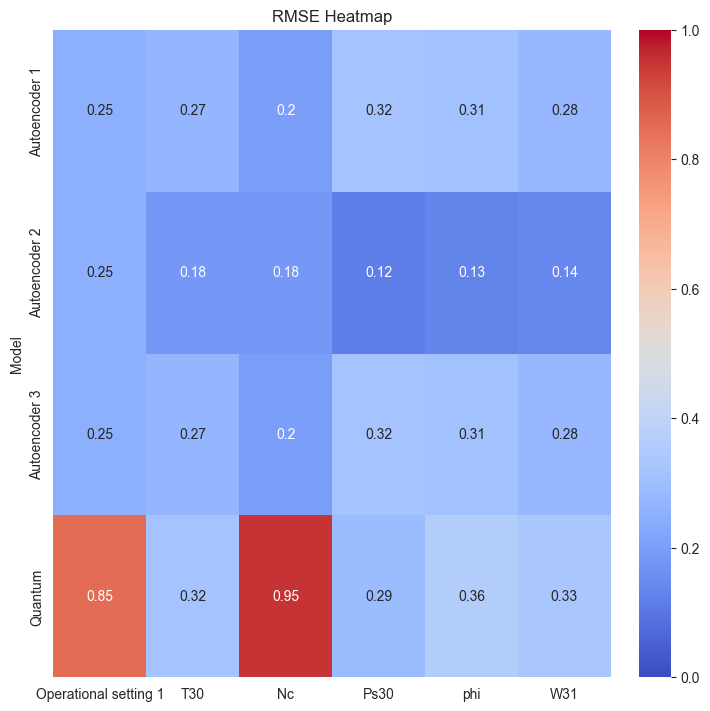

In [75]:
df_summary_heatmap = result_df.xs('RMSE', level=1)
fig, axes = plt.subplots(figsize=(7,7),
                            # dpi=300,
                            layout='constrained',
                            )
sns.heatmap(df_summary_heatmap.round(2), annot=True,
            cmap='coolwarm', vmin=0,vmax=1,fmt='.2g', ax=axes)
axes.set_title('RMSE Heatmap')
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Summary RMSE Heatmap.png')

## Boxplot

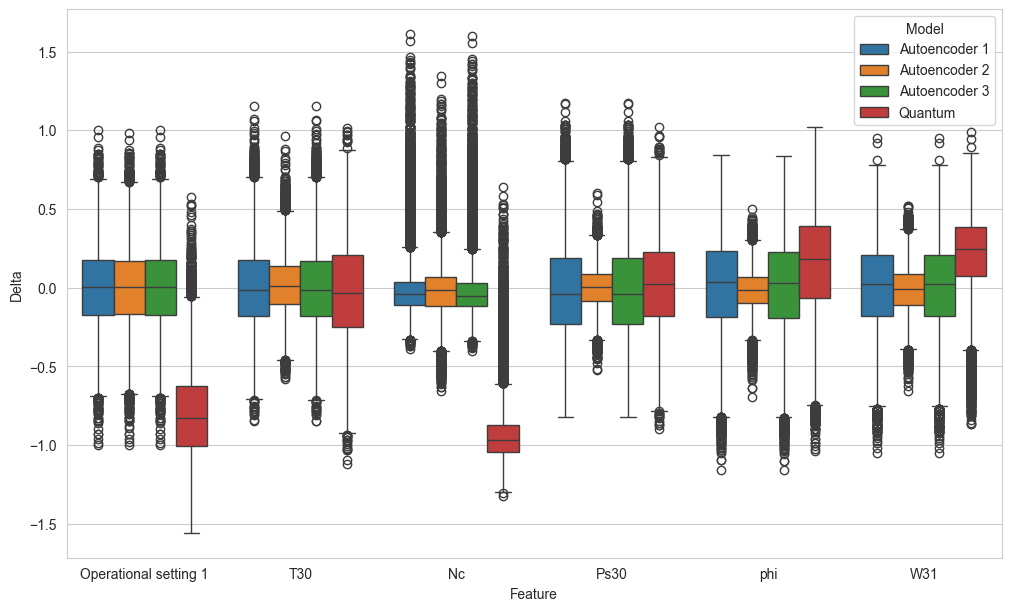

In [76]:
delta_df_list = []

for model_name in models_dict.keys():
    
    delta_df = models_dict[model_name]['Delta DF'].copy()
    delta_df['Model'] = model_name
    delta_df_list.append(delta_df)

delta_df_all = pd.concat(delta_df_list, ignore_index=True)
delta_df_all_melted = delta_df_all.melt(id_vars='Model', var_name='Feature', value_name='Delta')

fig, axes = plt.subplots(figsize=(10,6),
                            # dpi=300,
                            layout='constrained',
                            )
sns.boxplot(data=delta_df_all_melted, x='Feature', y='Delta', hue='Model', ax=axes)
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Delta Boxplots.png')

# Genral Summary over full df

In [77]:
df_summary = pd.DataFrame(index=['RMSE','Training time (s)','Epochs'])
for model in models_dict.keys():
    df_summary[model] = [
        models_dict[model]['MSE']**0.5,
        models_dict[model]['Training time'],
        models_dict[model]['Epochs']
    ]

df_summary = df_summary.round(4)
df_summary

,Autoencoder 1,Autoencoder 2,Autoencoder 3,Quantum
RMSE,0.2746,0.1733,0.2746,0.5853
Training time (s),1.8888,3.1367,2.0152,291.3246
Epochs,298.0000,1000.0000,255.0000,35.0000


## Save to latex

In [78]:
def simple_highlight(df):
    styles = pd.DataFrame("", index=df.index, columns=df.columns)

    for metric in df.index:
        row = df.loc[metric,:]

        best = row.idxmin()   # najbliżej 0
        worst  = row.idxmax()   # najdalej od 0

        styles.loc[metric,best]  = "background-color: #d1e7dd"
        styles.loc[metric,worst] = "background-color: #f8d7da"
        
    return styles

styled= (
    df_summary
    .style
    .apply(simple_highlight, axis=None)
    .format("{:.4f}")
)

latex = styled.to_latex(
    hrules=False,
    convert_css=True,
)

for col in list(df_summary.columns):
    latex = latex.replace(col, r'\textbf{' + col + '}')

with open(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/reconstruction_simple_summary.tex', "w") as text_file:
    text_file.write(latex)

## Barplot of RMSE comparison

In [79]:
df_summary_vis = df_summary.reset_index(names='Metric')
df_summary_vis = df_summary_vis.melt(id_vars='Metric', var_name='Model', value_name='Value')
df_summary_vis

,Metric,Model,Value
0,RMSE,Autoencoder 1,0.2746
1,Training time (s),Autoencoder 1,1.8888
2,Epochs,Autoencoder 1,298.0000
3,RMSE,Autoencoder 2,0.1733
4,Training time (s),Autoencoder 2,3.1367
5,Epochs,Autoencoder 2,1000.0000
6,RMSE,Autoencoder 3,0.2746
7,Training time (s),Autoencoder 3,2.0152
8,Epochs,Autoencoder 3,255.0000
9,RMSE,Quantum,0.5853


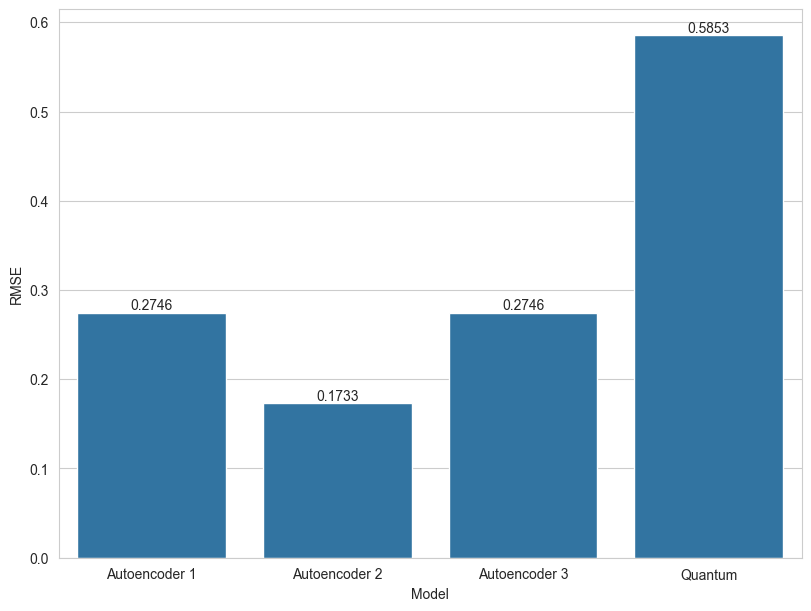

In [80]:
fig, axes = plt.subplots(figsize=(8,6),
                            # dpi=300,
                            layout='constrained',
                            )
sns.barplot(data=df_summary_vis.loc[df_summary_vis['Metric']=='RMSE'], 
            x='Model', y='Value', ax=axes)

for container in axes.containers:
    axes.bar_label(container)
    
axes.set_ylabel('RMSE')
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Summary RMSE Barplot.png')

## Barplot of training times

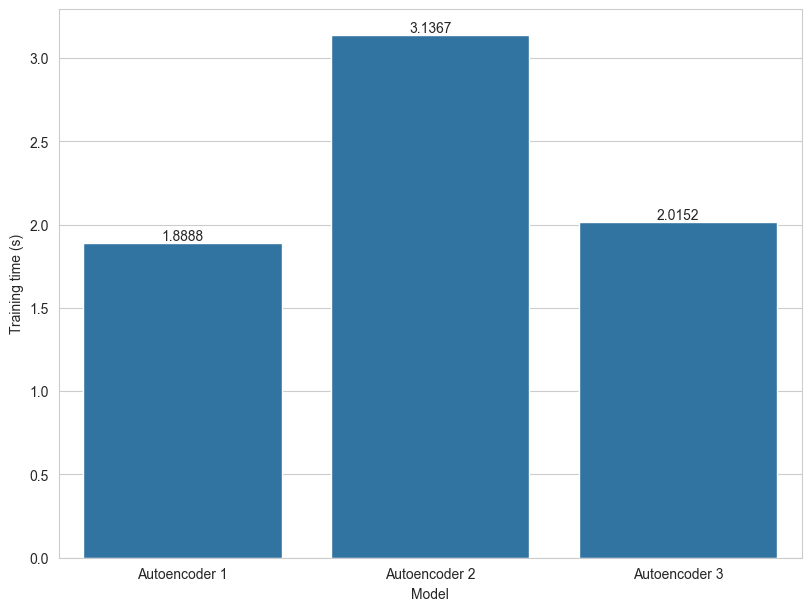

In [81]:
fig, axes = plt.subplots(figsize=(8,6),
                            # dpi=300,
                            layout='constrained',
                            )
sns.barplot(data=df_summary_vis.loc[(df_summary_vis['Metric']=='Training time (s)')&(df_summary_vis['Model']!='Quantum')], 
            x='Model', y='Value', ax=axes)

for container in axes.containers:
    axes.bar_label(container)
    
axes.set_ylabel('Training time (s)')
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Summary Time Barplot.png')

# Histograms of reconstruction errors for each model and feature

In [82]:
quantum_hist_df = models_dict['Quantum']['Delta DF']
quantum_hist_df['Model'] = 'Quantum'
model1_hist_df = models_dict['Autoencoder 2']['Delta DF']
model1_hist_df['Model'] = 'Autoencoder 2'
df_hist = pd.concat([quantum_hist_df, model1_hist_df], axis=0)


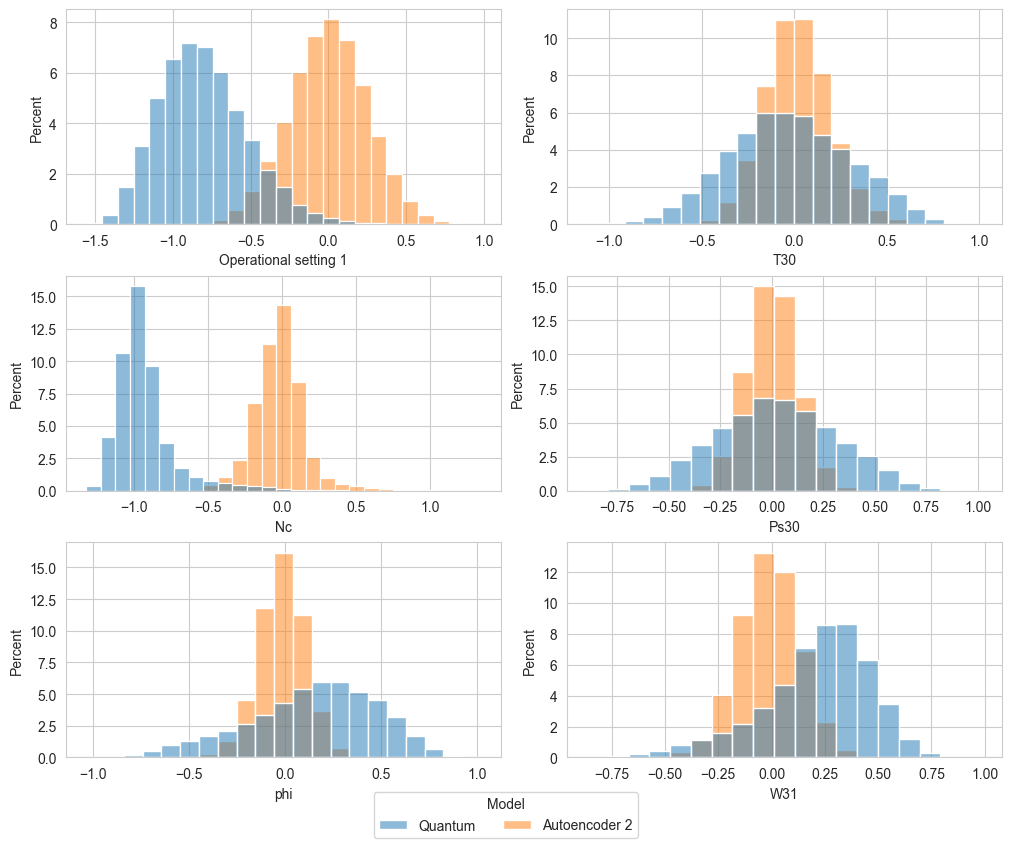

In [83]:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         figsize=(10, 8),
                         layout='constrained')
for i, (ax, feature) in enumerate(zip(axes.flat, df_hist.columns[:-1])):
    sns.histplot(
        data=df_hist,
        x=feature,
        hue='Model',
        binwidth=0.1,
        stat='percent',
        multiple="layer",
        ax=ax,
        legend=(i==0)  # <-- tylko pierwszy subplot ma legendę
    )

leg = axes.flat[0].get_legend()

handles = leg.legend_handles
labels = [t.get_text() for t in leg.texts]
axes.flat[0].legend_.remove()  # usuń oryginalną legendę


fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.05),
    ncol=2,
    title='Model'
)


fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_vs_AE1_Histograms.png', dpi=300,  bbox_inches='tight')

# Loss vs epochs plot

## Neural

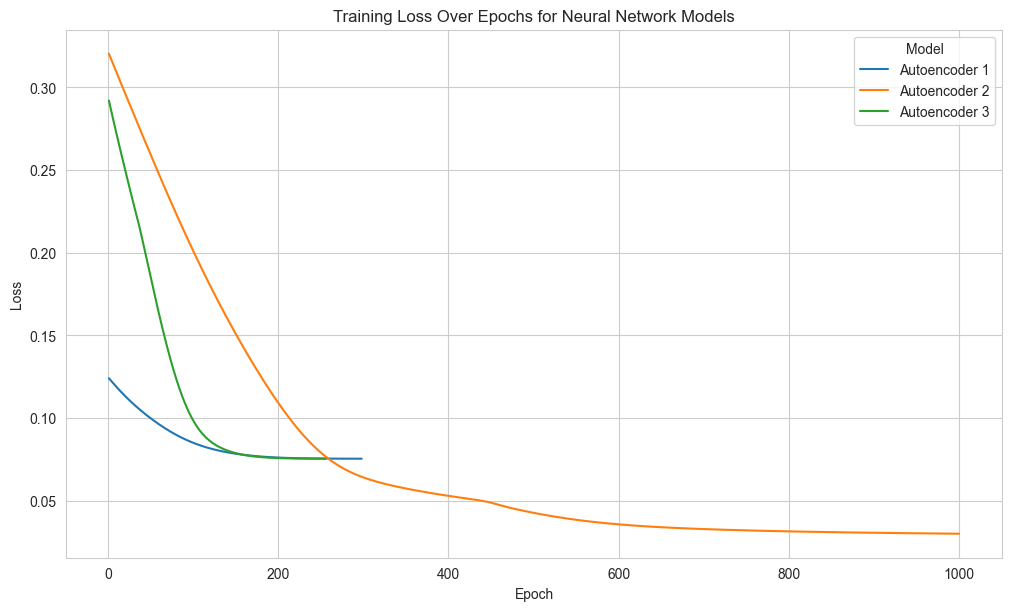

In [84]:
df_loss_list = []

for model_name in models_dict.keys():  # exclude Quantum model
    if model_name == "Quantum":
        continue
    epochs = models_dict[model_name]['Epochs']

    df_loss1 = pd.DataFrame(
        {
        'Epoch': range(1, epochs + 1),
        'Loss': models_dict[model_name]['Losses'],
        })
    df_loss1['Model'] = model_name
    df_loss_list.append(df_loss1)


df_losses = pd.concat(df_loss_list)

fig, axes = plt.subplots(figsize=(10, 6), layout='constrained')
sns.lineplot(data=df_losses, x='Epoch', y='Loss', hue='Model', ax=axes)
axes.set_title('Training Loss Over Epochs for Neural Network Models')

fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Neural_Training_Loss_Comparison.png', dpi=300)

## Quantum

In [85]:
df_losses_quantum = pd.DataFrame().from_dict(models_dict['Quantum']['Losses'])

df_losses_quantum

,Epoch,Total loss,Reconstruction loss,Compression loss
0,0,0.667733,0.413667,0.508133
1,1,0.481958,0.138067,0.687783
2,2,0.283483,0.120618,0.325731
3,3,0.190005,0.087749,0.204511
4,4,0.186956,0.086767,0.200377
5,5,0.186698,0.086737,0.199924
6,6,0.186573,0.086581,0.199983
7,7,0.186642,0.086647,0.199991
8,8,0.186633,0.086667,0.199931
9,9,0.186579,0.086605,0.199948


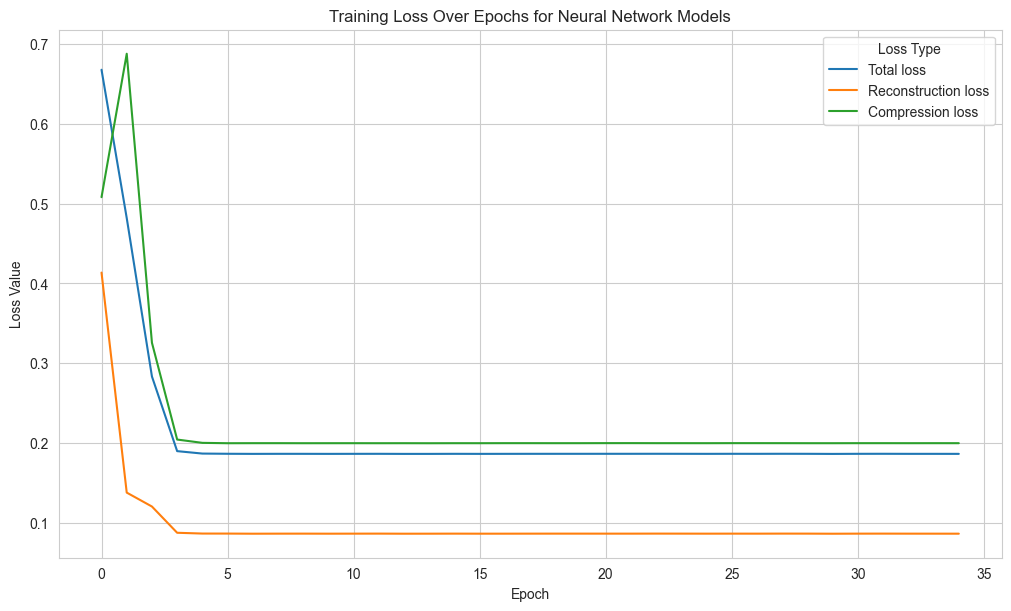

In [86]:
df_losses_quantum = pd.DataFrame().from_dict(models_dict['Quantum']['Losses'])
df_losses_quantum=df_losses_quantum.melt(id_vars='Epoch',var_name='Loss Type', value_name='Loss Value')
fig, axes = plt.subplots(figsize=(10, 6), layout='constrained')
sns.lineplot(data=df_losses_quantum, x='Epoch',y='Loss Value',hue='Loss Type', ax=axes)
axes.set_title('Training Loss Over Epochs for Neural Network Models')

fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_Training_Loss_Comparison.png', dpi=300)

# Visualize model architectures

<function torchviz.dot.make_dot(var, params=None, show_attrs=False, show_saved=False, max_attr_chars=50)>

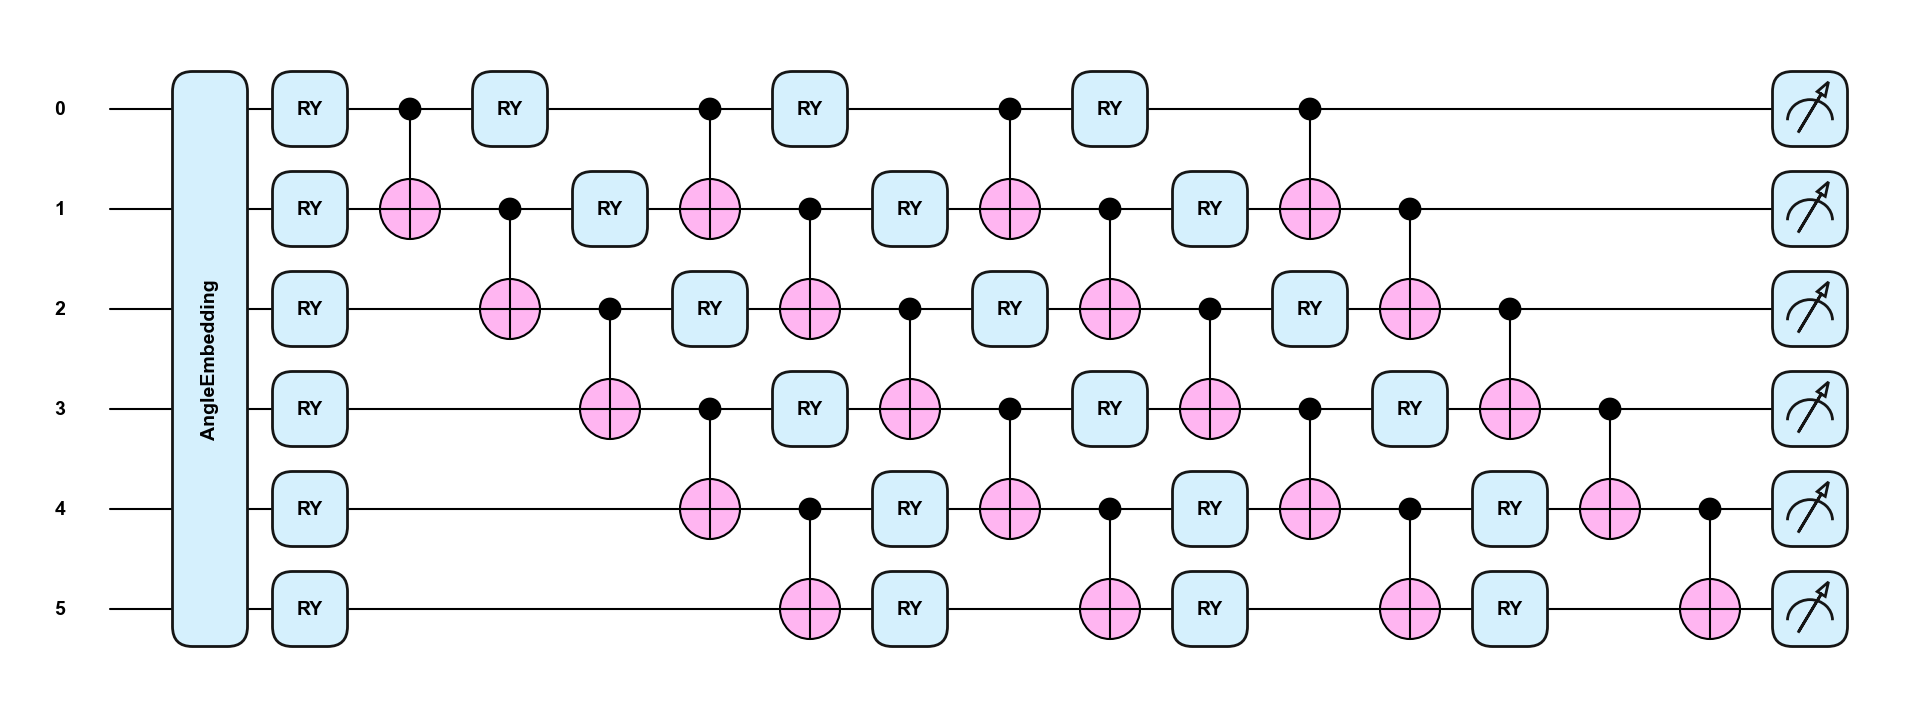

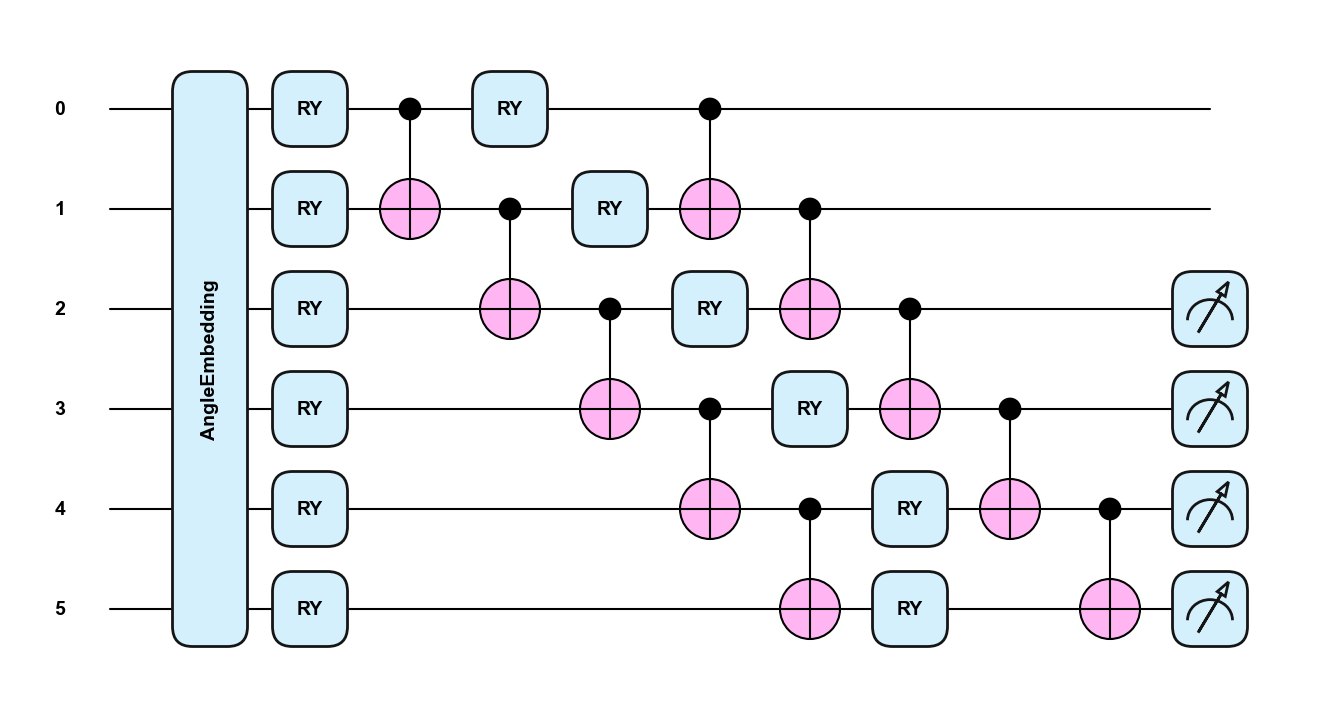

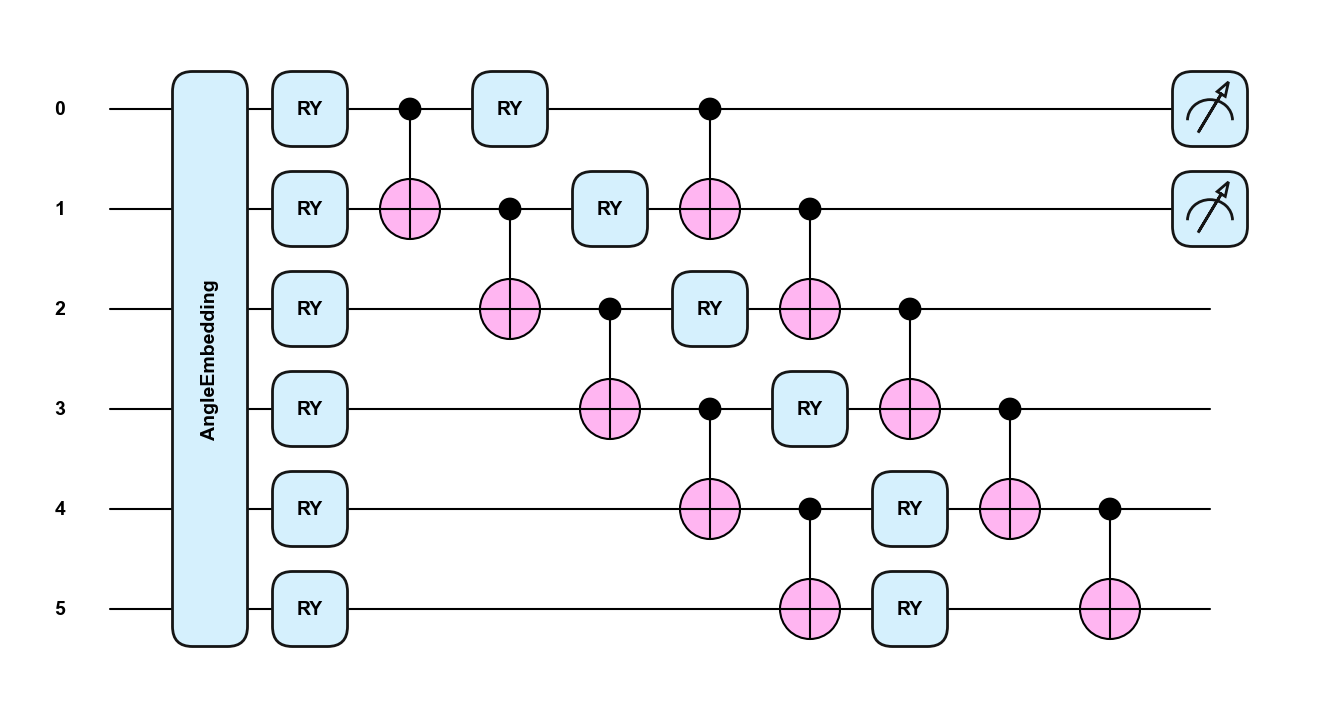

In [87]:
qml.drawer.use_style("pennylane")

# Draw a QNode (decode_qnode_batch) — pass sample inputs with correct shapes.
sample_x = np.ones(n_qubits) * (np.pi / 4)  # length n_qubits
sample_encoder_weight = model4.encoder_weight.detach().cpu().numpy()
sample_decoder_weight = model4.decoder_weight.detach().cpu().numpy()

fig, ax = qml.draw_mpl(decode_qnode_batch,show_all_wires=True,show_wire_labels =True)(sample_x, sample_encoder_weight, sample_decoder_weight)
fig.savefig(f'{filepath}/Output/Model_Analysis/Quantum_Autoencoder_Decoder_QNode.png', dpi=300)
fig, ax = qml.draw_mpl(trash_zero_qnode_batch,show_all_wires=True,show_wire_labels =True)(sample_x, sample_encoder_weight)
fig.savefig(f'{filepath}/Output/Model_Analysis/Quantum_Autoencoder_Trash_Zero_QNode.png', dpi=300)
fig, ax = qml.draw_mpl(latent_state_values,show_all_wires=True,show_wire_labels =True)(sample_x, sample_encoder_weight)
fig.savefig(f'{filepath}/Output/Model_Analysis/Quantum_Autoencoder_Latent_State_QNode.png', dpi=300)

make_dot

# Visualize latent representation extraction

## Quantum

In [88]:
latents = []
for i in tqdm(range(len(X))):  # pierwsze 10 próbek
    z = latent_state_values(X[i], models_dict['Quantum']['Model'].encoder_weight)
    z= [x.detach().numpy() for x in z]
    latents.append(z)

latents = np.array(latents)
latents_df = pd.DataFrame(latents, columns=[f'Latent Qubit {i}' for i in range(n_latent)])

latents_df.head(10).to_csv(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_Autoencoder_Latent_Representations.csv', index=False,)

with open(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/latent_quantum.tex', "w") as text_file:
    text_file.write(latents_df.head(10).to_latex(index=False, float_format="%.4f"))

100%|██████████| 20631/20631 [04:53<00:00, 70.20it/s]


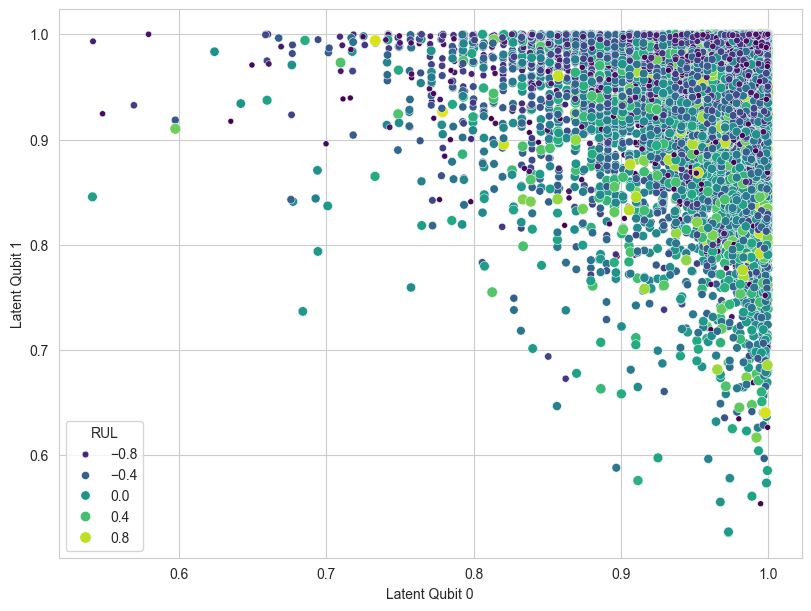

In [89]:
latents_df['RUL']= df_original['RUL']
fig, axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.scatterplot(data=latents_df, x='Latent Qubit 0', y='Latent Qubit 1',ax=axes, hue='RUL',size='RUL',palette='viridis')
#axes.set_title('Latent Space Representations from Quantum Autoencoder')
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_Autoencoder_Latent_Space.png', dpi=300)

In [103]:
latents_df.describe().loc[['min','max'],:].to_clipboard()

In [90]:
with open(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/latent_quantum.tex', "w") as text_file:
    text_file.write(latents_df.head(10).to_latex(index=False, float_format="%.4f"))

## Neural

[-0.05821596 -0.05821596 -0.05821597]


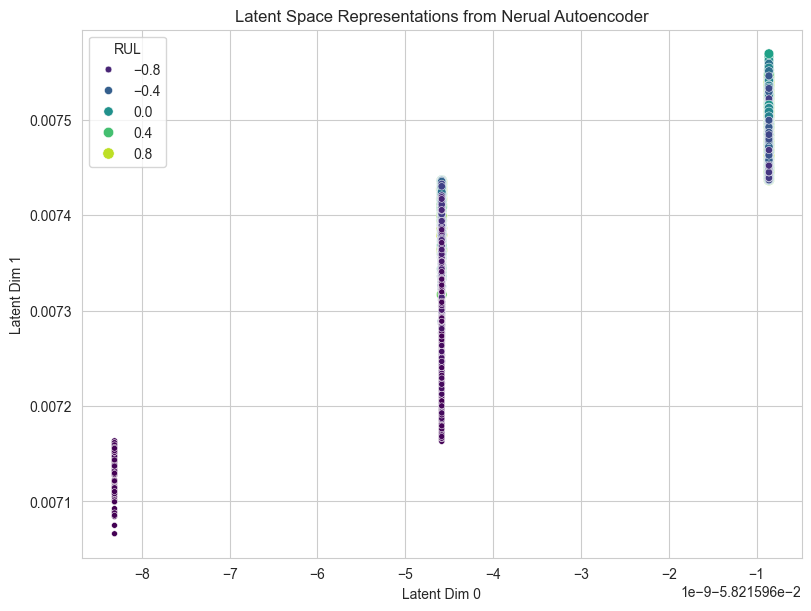

In [ ]:
latent_neural = models_dict['Autoencoder 1']['Model'].encoder(torch.tensor(df.values, dtype=torch.float32)).detach().numpy()
latents_df_neural = pd.DataFrame(latent_neural, columns=[f'Latent Dim {i}' for i in range(latent_neural.shape[1])])
latents_df_neural['RUL'] = df_original['RUL']
fig, axes = plt.subplots(figsize=(8, 6), layout='constrained')
sns.scatterplot(data=latents_df_neural, x='Latent Dim 0', y='Latent Dim 1',hue='RUL',size='RUL',palette='viridis')
axes.set_title('Latent Space Representations from Nerual Autoencoder')
fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Neural_Autoencoder_Latent_Space.png')




latents_df_neural[['Latent Dim 0','Latent Dim 1']].head(10).to_latex(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/latent_neural.tex',
                                                                     index=False, float_format="%.4f")


In [100]:
print(latents_df_neural['Latent Dim 1'].min(),
latents_df_neural['Latent Dim 1'].max())

0.0070660585 0.007569175


# Reconstructed vs original feature vs plot 

In [92]:
df_recon_ae1 = models_dict['Autoencoder 2']['Reconstructed DF']
df_recon_aeq =models_dict['Quantum']['Reconstructed DF']

df_recon_ae1['Data']='Autoencoder 2'
df_recon_aeq['Data']='Quantum'

df_recon_ae1['RUL'] =df_recon_aeq['RUL']= df_original['RUL']

df_combined = pd.concat([df_original, df_recon_ae1,df_recon_aeq], axis=0)
df_combined=df_combined[df_recon_ae1.columns]
df_combined.head()

,Operational setting 1,T30,Nc,Ps30,phi,W31,Data,RUL
0,-0.080460,-0.186396,-0.780490,-0.261905,0.266525,0.426357,Original,0.058172
1,0.218391,-0.093961,-0.799515,-0.238095,0.530917,0.333333,Original,0.052632
2,-0.494253,-0.260955,-0.719914,-0.500000,0.590618,0.255814,Original,0.047091
3,0.080460,-0.487683,-0.750965,-0.666667,0.778252,0.147287,Original,0.041551
4,-0.218391,-0.485066,-0.700081,-0.488095,0.492537,0.178295,Original,0.036011


## Scatterplot

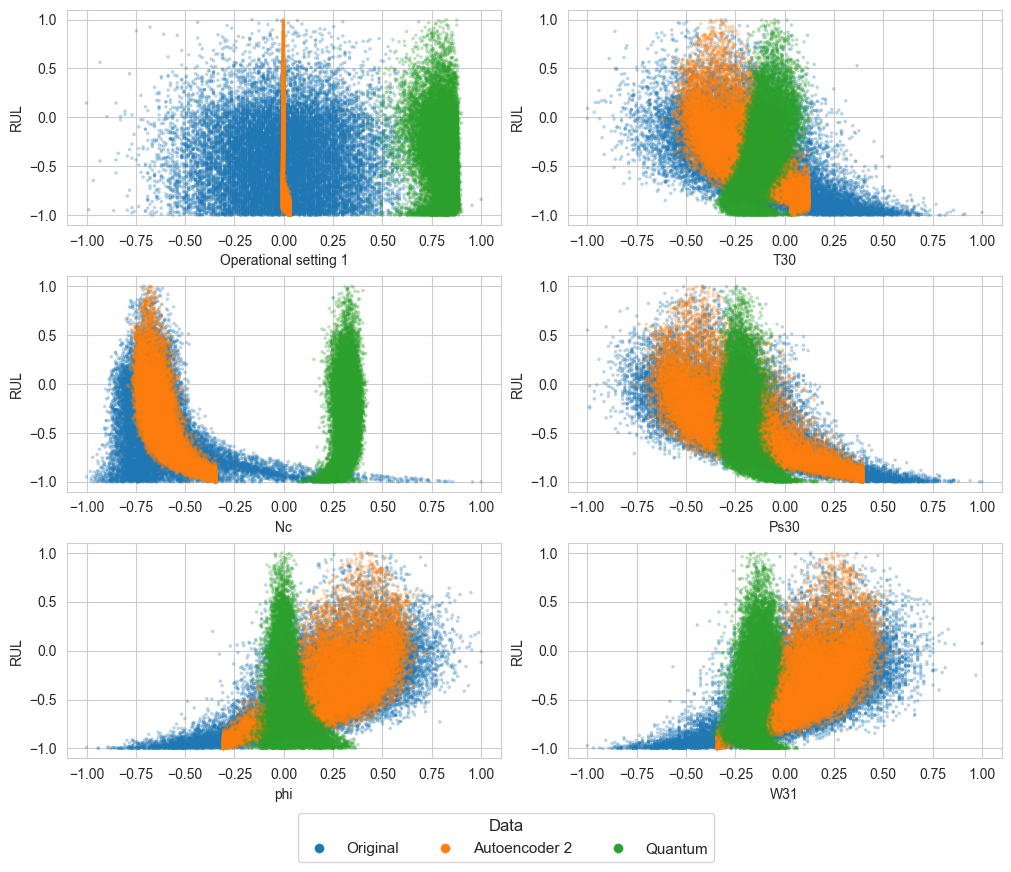

In [93]:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         figsize=(10, 8),
                         layout='constrained')
for i, (ax, feature) in enumerate(zip(axes.flat, df.columns)):
    sns.scatterplot(
        data=df_combined,
        y='RUL',
        x=feature,
        hue='Data',s=5, alpha=0.3, edgecolor=None,
        ax=ax,
        legend=(i==0)  # <-- tylko pierwszy subplot ma legendę
    )
    

leg = axes.flat[0].get_legend()

handles = leg.legend_handles
labels = [t.get_text() for t in leg.texts]
axes.flat[0].legend_.remove()  # usuń oryginalną legendę


for h in handles:
    try:
        h.set_alpha(1.0)
    except AttributeError:
        pass


fig.legend(
    handles,
    labels,
    loc='lower center',
    bbox_to_anchor=(0.5, -0.08),
    ncol=3,
    title='Data',
    fontsize=11,
    title_fontsize=12,
    markerscale=3,
    
    frameon=True
)



fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/AE_vs_original_scatter.png', dpi=300,  bbox_inches='tight')

## Hexbin

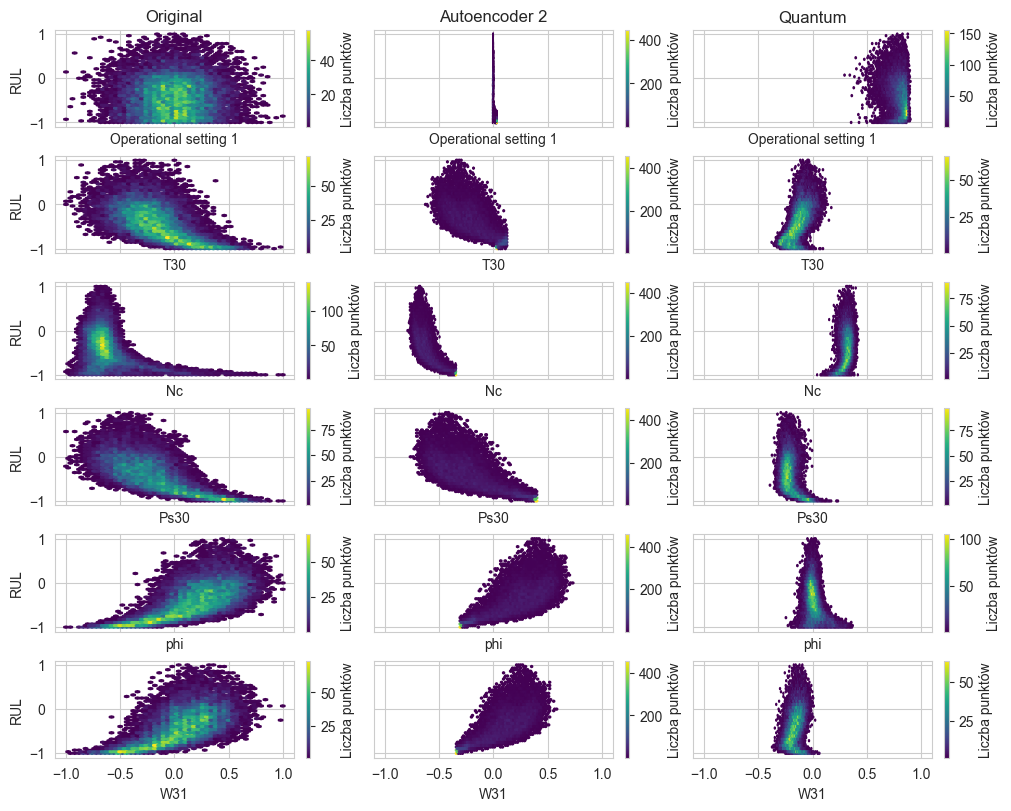

In [94]:
fig, axes = plt.subplots(nrows=len(df.columns), ncols=3,
                         figsize=(10, 8),
                         layout='constrained',
                         sharex=True,
                         sharey=True)
for i, feature in enumerate( df.columns):
    for j, model in enumerate(['Original', 'Autoencoder 2', 'Quantum']):
        df_hex = df_combined.loc[df_combined['Data']==model]
        hb1= axes[i,j].hexbin(
        df_hex[feature], 
        df_hex['RUL'], 
        gridsize=50,      
        cmap='viridis',  
        mincnt=1)
        if i ==0:
            axes[i, j].set_title(model)
        if j==0:
            axes[i,j].set_ylabel("RUL")
        
        axes[i,j].set_xlabel(feature)
        fig.colorbar(hb1, ax=axes[i, j], label='Liczba punktów')




# Trzeba dodać colorbar, żeby wiedzieć co oznacza kolor
    
#fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_vs_AE1_Histograms.png', dpi=300,  bbox_inches='tight')

## Violinplot

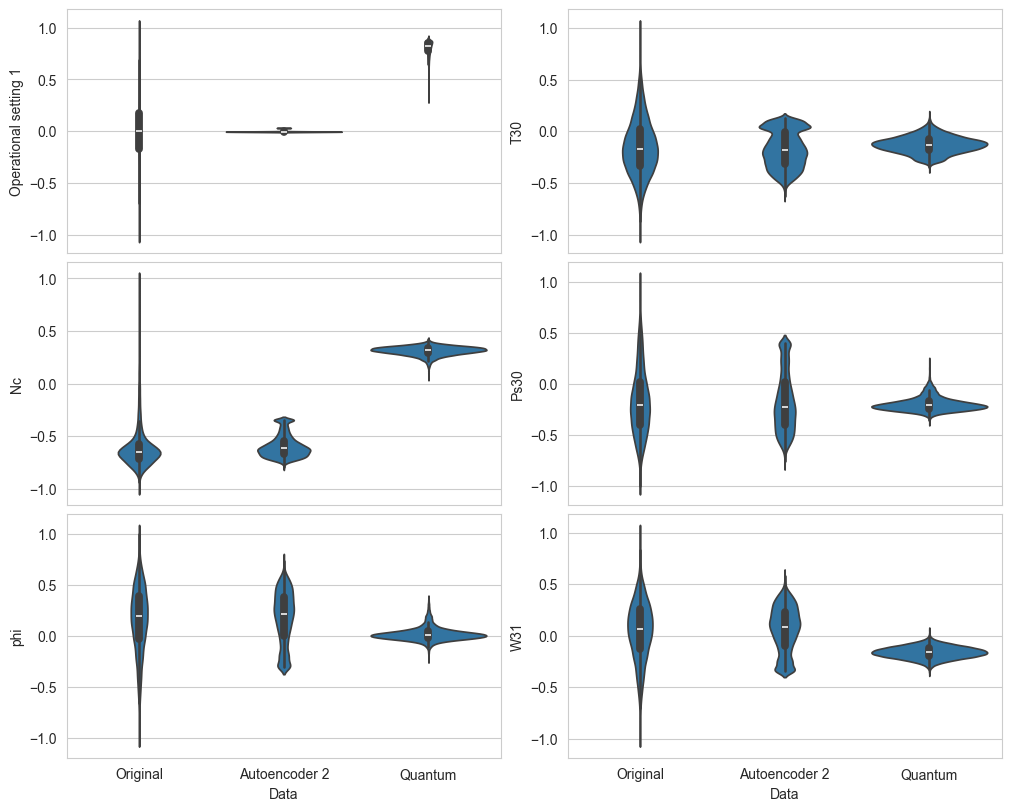

In [95]:
fig, axes = plt.subplots(nrows=3, ncols=2,
                         figsize=(10, 8),
                         layout='constrained',
                         sharex=True,
                         )
for i, (ax, feature) in enumerate(zip(axes.flat, df.columns)):
    sns.violinplot(
        data=df_combined,
        x='Data',
        y=feature,
        #hue='Data',
        ax=ax,
        legend=(i==0)  # <-- tylko pierwszy subplot ma legendę
    )
    





fig.savefig(f'{filepath}/Pisanie/Latex/Output/Model_Analysis/Quantum_vs_AE_Violin.png', dpi=300,  bbox_inches='tight')